# ДЗ 11. Машинний переклад з фінської на англійську: Seq2Seq з увагою

Набір даних Helsinki-NLP/europarl

Модель: енкодер на двонаправленому GRU і декодер на GRU з адитивною увагою (Bahdanau et al., 2015).

In [1]:
import importlib.util, subprocess, sys

for pkg in ["datasets", "spacy", "nltk"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

In [2]:
import copy
import math
import random
import textwrap
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import spacy
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Sampler
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

COLORS = {"train": "#2a78d6", "val": "#eb6834"}
LANG_COLORS = {"fi": "#2a78d6", "en": "#eb6834"}
INK, AXIS = "#52514e", "#c3c2b7"
ATTN_CMAP = LinearSegmentedColormap.from_list(
    "attn", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": AXIS,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2, "legend.frameon": False,
})

device: mps


## Дані

Конфіг en-fi: майже 2 млн пар речень, одна вибірка train. Беру випадкові 5%.

In [3]:
SRC_LANG, TRG_LANG = "fi", "en"
SUBSET = 0.05

raw = load_dataset("Helsinki-NLP/europarl", "en-fi", split="train", cache_dir="data")
n_subset = int(SUBSET * len(raw))
df = raw.shuffle(seed=SEED).select(range(n_subset)).flatten().to_pandas()
df.columns = [c.split(".")[-1] for c in df.columns]   # translation.fi -> fi
for lang in (SRC_LANG, TRG_LANG):
    df[lang] = df[lang].str.strip()

print(f"пар у корпусі: {len(raw):,}, у підмножині: {len(df):,}")
for _, row in df.head(3).iterrows():
    print(f"\nfi: {row.fi}\nen: {row.en}")

пар у корпусі: 1,969,624, у підмножині: 98,481

fi: Euroopan parlamentissa on aiemminkin kuultu tämänkaltaisia keskusteluja, ja ne alkavat minusta jo muistuttaa sisältöä vailla olevia rituaaleja.
en: I have attended more debates like this than I care to remember here in the European Parliament and at some point they start to sound like empty liturgies.

fi: Vaadimme paljon enemmän, vaadimme tällä hetkellä toimivan UCLAFin korvaamista petostentorjunnasta vastaavalla virastolla, jonka toiminta on täysin riippumatonta, mutta joka ei toimi satelliittina jossakin EU: n toimielinten ulkopuolella.
en: Instead, we want the current UCLAF to be replaced by an office of fraud prevention with full operational independence, but not one that is a satellite organisation somewhere outside the institutions of the EU.

fi: Esityslistalla on seuraavana Brokin laatima ulkoasioiden, ihmisoikeuksien sekä yhteisen turvallisuuden ja puolustuspolitiikan valiokunnan mietintö (A5-0332/2001) yhteisen ulko- ja tur

## Токенізація


In [4]:
nlp = {lang: spacy.blank(lang) for lang in (SRC_LANG, TRG_LANG)}

def tokenize(texts, lang):
    docs = nlp[lang].tokenizer.pipe((t.lower() for t in texts), batch_size=2000)
    return [[tok.text for tok in doc if not tok.is_space] for doc in docs]

df["src_tok"] = tokenize(df[SRC_LANG], SRC_LANG)
df["trg_tok"] = tokenize(df[TRG_LANG], TRG_LANG)
df["src_len"] = df.src_tok.map(len)
df["trg_len"] = df.trg_tok.map(len)

print(df.src_tok[0])
print(df.trg_tok[0])
print()
print(df[["src_len", "trg_len"]].describe(percentiles=[0.5, 0.9]).round(1).T)
print("\nмедіана відношення довжин en/fi:", (df.trg_len / df.src_len.clip(lower=1)).median().round(2))

['euroopan', 'parlamentissa', 'on', 'aiemminkin', 'kuultu', 'tämänkaltaisia', 'keskusteluja', ',', 'ja', 'ne', 'alkavat', 'minusta', 'jo', 'muistuttaa', 'sisältöä', 'vailla', 'olevia', 'rituaaleja', '.']
['i', 'have', 'attended', 'more', 'debates', 'like', 'this', 'than', 'i', 'care', 'to', 'remember', 'here', 'in', 'the', 'european', 'parliament', 'and', 'at', 'some', 'point', 'they', 'start', 'to', 'sound', 'like', 'empty', 'liturgies', '.']

           count  mean   std  min   50%   90%    max
src_len  98481.0  19.4  11.4  1.0  17.0  34.0  162.0
trg_len  98481.0  27.6  16.4  1.0  25.0  49.0  286.0

медіана відношення довжин en/fi: 1.41


## Фільтрація і розбиття на вибірки

Лишаю пари, де в обох реченнях від 3 до 30 токенів. Нижня межа відсікає сміття на кшталт пар
"." / ".", верхня прибирає довгі речення: вони сильно сповільнюють цикл декодера.

Розбиття 90/5/5. Валідація потрібна для кривих втрат і вибору найкращої епохи, тест використовую
тільки в кінці, для BLEU і прикладів перекладу.

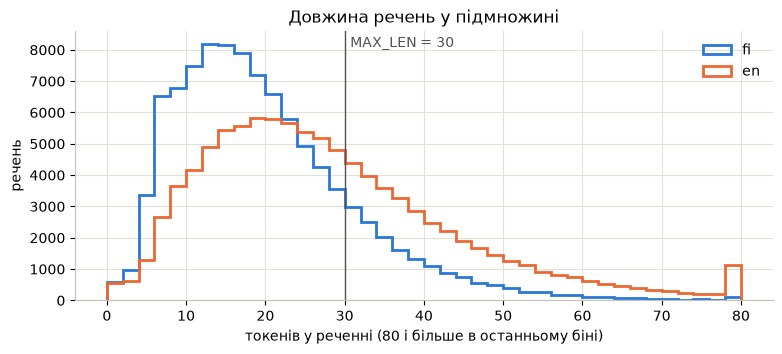

в межах 3-30 токенів: 62,552, без дублікатів: 61,196
train: 55,076  val: 3,060  test: 3,060


In [5]:
MIN_LEN, MAX_LEN = 3, 30

fig, ax = plt.subplots(figsize=(9, 3.5))
bins = np.arange(0, 82, 2)
for lang, col in [(SRC_LANG, "src_len"), (TRG_LANG, "trg_len")]:
    ax.hist(df[col].clip(upper=80), bins=bins, histtype="step", lw=2, color=LANG_COLORS[lang], label=lang)
ax.axvline(MAX_LEN, color=INK, lw=1)
ax.annotate(f"MAX_LEN = {MAX_LEN}", xy=(MAX_LEN, 1), xycoords=("data", "axes fraction"),
            xytext=(4, -4), textcoords="offset points", va="top", color=INK)
ax.set_xlabel("токенів у реченні (80 і більше в останньому біні)")
ax.set_ylabel("речень")
ax.set_title("Довжина речень у підмножині")
ax.legend()
plt.show()

keep = df.src_len.between(MIN_LEN, MAX_LEN) & df.trg_len.between(MIN_LEN, MAX_LEN)
pairs = (df[keep].drop_duplicates(subset=SRC_LANG).drop_duplicates(subset=TRG_LANG)
         .reset_index(drop=True))
print(f"в межах {MIN_LEN}-{MAX_LEN} токенів: {keep.sum():,}, без дублікатів: {len(pairs):,}")

train_df, rest_df = train_test_split(pairs, test_size=0.1, random_state=SEED)
val_df, test_df = train_test_split(rest_df, test_size=0.5, random_state=SEED)
train_df, val_df, test_df = (d.reset_index(drop=True) for d in (train_df, val_df, test_df))
print(f"train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}")

## Словники

Словники будую тільки на train. У словник іде слово, яке трапилося хоча б двічі, решта стає `<unk>`.

In [6]:
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = range(4)
MIN_FREQ = 2

class Vocab:
    def __init__(self, token_lists, min_freq):
        counter = Counter(tok for tokens in token_lists for tok in tokens)
        words = sorted((w for w, c in counter.items() if c >= min_freq), key=lambda w: (-counter[w], w))
        self.itos = [PAD, SOS, EOS, UNK] + words
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def encode(self, tokens):
        return [self.stoi.get(tok, UNK_IDX) for tok in tokens]

    def decode(self, ids):
        return [self.itos[i] for i in ids]


src_vocab = Vocab(train_df.src_tok, MIN_FREQ)
trg_vocab = Vocab(train_df.trg_tok, MIN_FREQ)

def oov_rate(frame, col, vocab):
    return np.mean([tok not in vocab.stoi for tokens in frame[col] for tok in tokens])

print(f"словник {SRC_LANG}: {len(src_vocab):,} слів, невідомих токенів на val: {oov_rate(val_df, 'src_tok', src_vocab):.1%}")
print(f"словник {TRG_LANG}: {len(trg_vocab):,} слів, невідомих токенів на val: {oov_rate(val_df, 'trg_tok', trg_vocab):.1%}")
print("\nнайчастіші fi:", src_vocab.itos[4:20])
print("найчастіші en:", trg_vocab.itos[4:20])
print("\nформи komissio у словнику:", [w for w in src_vocab.itos if w.startswith("komissio")][:10])

словник fi: 32,246 слів, невідомих токенів на val: 9.4%
словник en: 13,261 слів, невідомих токенів на val: 1.4%

найчастіші fi: ['.', ',', 'on', 'ja', 'että', 'ei', 'euroopan', 'se', 'myös', 'ovat', 'tämä', 'arvoisa', 'ole', 'sen', 'puhemies', 'meidän']
найчастіші en: ['the', '.', ',', 'to', 'of', 'and', 'in', 'is', 'that', 'a', 'we', 'this', 'i', 'for', 'it', 'be']

форми komissio у словнику: ['komission', 'komissio', 'komissiota', 'komissiolle', 'komissiolta', 'komissiossa', 'komissiolla', 'komissioon', 'komissiosta', 'komissiokin']


## Ітератори даних

Речення перетворюю на індекси: до джерела додаю `<eos>`, ціль обгортаю в `<sos> ... <eos>`.

In [7]:
BATCH_SIZE = 128

def encode_pairs(frame):
    return [(src_vocab.encode(s) + [EOS_IDX], [SOS_IDX] + trg_vocab.encode(t) + [EOS_IDX])
            for s, t in zip(frame.src_tok, frame.trg_tok)]

train_data, val_data, test_data = encode_pairs(train_df), encode_pairs(val_df), encode_pairs(test_df)


class BucketBatchSampler(Sampler):
    def __init__(self, lengths, batch_size, shuffle, chunk_batches=50, seed=SEED):
        self.lengths = np.asarray(lengths)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.chunk = batch_size * chunk_batches
        self.rng = np.random.default_rng(seed)

    def __iter__(self):
        n = len(self.lengths)
        idx = self.rng.permutation(n) if self.shuffle else np.arange(n)
        batches = []
        for start in range(0, n, self.chunk):
            part = idx[start:start + self.chunk]
            part = part[np.argsort(self.lengths[part], kind="stable")]
            batches += [part[i:i + self.batch_size].tolist() for i in range(0, len(part), self.batch_size)]
        if self.shuffle:
            batches = [batches[i] for i in self.rng.permutation(len(batches))]
        return iter(batches)

    def __len__(self):
        return math.ceil(len(self.lengths) / self.batch_size)


def collate(batch):
    src, trg = zip(*batch)
    src_len = torch.tensor([len(s) for s in src])   # лишається на CPU, так хоче pack_padded_sequence
    src = pad_sequence([torch.tensor(s) for s in src], batch_first=True, padding_value=PAD_IDX)
    trg = pad_sequence([torch.tensor(t) for t in trg], batch_first=True, padding_value=PAD_IDX)
    return src, src_len, trg


def make_loader(data, shuffle):
    sampler = BucketBatchSampler([len(t) for _, t in data], BATCH_SIZE, shuffle)
    return DataLoader(data, batch_sampler=sampler, collate_fn=collate)


train_loader = make_loader(train_data, shuffle=True)
val_loader = make_loader(val_data, shuffle=False)

src, src_len, trg = next(iter(train_loader))
print("батчів за епоху:", len(train_loader))
print("src:", tuple(src.shape), " trg:", tuple(trg.shape))
print("перший приклад у батчі:")
print("  src:", src_vocab.decode(src[0, :src_len[0]].tolist()))
print("  trg:", trg_vocab.decode([i for i in trg[0].tolist() if i != PAD_IDX]))

батчів за епоху: 431
src: (128, 28)  trg: (128, 26)
перший приклад у батчі:
  src: ['katson', 'todellakin', ',', 'että', 'eurooppaa', 'voidaan', 'rakentaa', 'sitä', 'paremmin', ',', 'mitä', 'lähempänä', 'ollaan', '<unk>', 'kansalaisia', '.', '<eos>']
  trg: ['<sos>', 'i', 'do', 'indeed', 'consider', 'that', 'the', 'closer', 'we', 'get', 'to', 'the', 'citizens', 'that', 'elect', 'us', ',', 'the', 'better', 'europe', 'will', 'be', 'built', '.', '<eos>']


## Модель

**Енкодер.** Ембедінг і двонаправлений GRU. Паддінг пакую через `pack_padded_sequence`, інакше
зворотний GRU починав би читати речення з `<pad>`, а не з останнього слова. Для кожного токена
енкодер віддає стан $h_j$ (прямий і зворотний, зшиті, 512 чисел). Фінальні стани обох напрямків
через лінійний шар і tanh стають початковим станом декодера $s_0$.

**Декодер.** Один крок: ембедінг попереднього слова разом з $c_t$ іде в GRUCell, вихідний шар
бачить новий стан $s_t$, $c_t$ і той самий ембедінг. `Seq2Seq` проганяє енкодер і викликає декодер
крок за кроком.

In [8]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hid_dim, dec_hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_len):
        embedded = self.dropout(self.embedding(src))                                  # (B, S, E)
        packed = pack_padded_sequence(embedded, src_len.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.rnn(packed)                                         # hidden: (2, B, H)
        outputs, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=src.size(1))  # (B, S, 2H)
        hidden = torch.tanh(self.fc(torch.cat([hidden[0], hidden[1]], dim=1)))       # (B, H_dec)
        return outputs, hidden


class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim, attn_dim):
        super().__init__()
        self.W_enc = nn.Linear(enc_hid_dim * 2, attn_dim, bias=False)
        self.W_dec = nn.Linear(dec_hid_dim, attn_dim)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_keys, enc_outputs, mask):
        # enc_keys = W_enc(enc_outputs), рахується один раз у Seq2Seq.encode
        energy = torch.tanh(enc_keys + self.W_dec(dec_hidden).unsqueeze(1))          # (B, S, A)
        scores = self.v(energy).squeeze(2).masked_fill(~mask, float("-inf"))        # (B, S)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), enc_outputs).squeeze(1)            # (B, 2H)
        return context, weights


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hid_dim, dec_hid_dim, attn_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = Attention(enc_hid_dim, dec_hid_dim, attn_dim)
        self.rnn = nn.GRUCell(emb_dim + enc_hid_dim * 2, dec_hid_dim)
        self.fc_out = nn.Linear(dec_hid_dim + enc_hid_dim * 2 + emb_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token, hidden, enc_keys, enc_outputs, mask):
        # один крок: token (B,) це попереднє слово, hidden (B, H_dec) це s_{t-1}
        embedded = self.dropout(self.embedding(token))
        context, weights = self.attention(hidden, enc_keys, enc_outputs, mask)
        hidden = self.rnn(torch.cat([embedded, context], dim=1), hidden)
        logits = self.fc_out(torch.cat([hidden, context, embedded], dim=1))
        return logits, hidden, weights


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def encode(self, src, src_len):
        enc_outputs, hidden = self.encoder(src, src_len)
        enc_keys = self.decoder.attention.W_enc(enc_outputs)
        return enc_outputs, enc_keys, hidden, src != PAD_IDX

    def forward(self, src, src_len, trg):
        # teacher forcing: на кроці t на вхід іде справжнє слово trg[:, t], передбачаємо trg[:, t + 1]
        enc_outputs, enc_keys, hidden, mask = self.encode(src, src_len)
        logits = []
        for t in range(trg.size(1) - 1):
            out, hidden, _ = self.decoder(trg[:, t], hidden, enc_keys, enc_outputs, mask)
            logits.append(out)
        return torch.stack(logits, dim=1)                                             # (B, T-1, V)

In [9]:
EMB_DIM = 256
ENC_HID_DIM = 256
DEC_HID_DIM = 512
ATTN_DIM = 256
DROPOUT = 0.3

encoder = Encoder(len(src_vocab), EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT)
decoder = Decoder(len(trg_vocab), EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ATTN_DIM, DROPOUT)
model = Seq2Seq(encoder, decoder).to(device)
print(f"параметрів: {sum(p.numel() for p in model.parameters()) / 1e6:.1f} млн")

with torch.no_grad():
    logits = model(src.to(device), src_len, trg.to(device))
print("logits:", tuple(logits.shape), "= (batch, довжина цілі - 1, словник en)")

параметрів: 31.9 млн


logits: (128, 25, 13261) = (batch, довжина цілі - 1, словник en)


## Функція втрат і оптимізатор

`CrossEntropyLoss` з `ignore_index` на `<pad>`, щоб паддінг не потрапляв ні у втрати, ні в
градієнти. Adam, lr=1e-3. Норму градієнта обрізаю до 1: у рекурентній мережі градієнт проходить
через десятки кроків і час від часу вибухає.

In [10]:
LR = 1e-3
CLIP = 1.0
EPOCHS = 10

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

## Навчання

`train_epoch` повертає середню втрату на токен за епоху і втрату кожного батча для детальнішого
графіка. Середнє зважую кількістю справжніх токенів, бо в батчах з короткими реченнями їх менше.
Після кожної епохи рахую втрату на валідації і запам'ятовую ваги найкращої епохи.

In [11]:
def train_epoch(model, loader, optimizer, criterion, clip):
    model.train()
    total_loss, total_tokens, batch_losses = 0.0, 0, []
    for src, src_len, trg in loader:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        logits = model(src, src_len, trg)
        loss = criterion(logits.reshape(-1, logits.size(-1)), trg[:, 1:].reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        n_tokens = (trg[:, 1:] != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens
        batch_losses.append(loss.item())
    return total_loss / total_tokens, batch_losses


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for src, src_len, trg in loader:
        src, trg = src.to(device), trg.to(device)
        logits = model(src, src_len, trg)
        loss = criterion(logits.reshape(-1, logits.size(-1)), trg[:, 1:].reshape(-1))
        n_tokens = (trg[:, 1:] != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens
    return total_loss / total_tokens

In [12]:
history = {"train": [], "val": []}
batch_history = []
best_val_loss, best_epoch, best_state = float("inf"), 0, None

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, batch_losses = train_epoch(model, train_loader, optimizer, criterion, CLIP)
    val_loss = evaluate(model, val_loader, criterion)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    batch_history += batch_losses

    if val_loss < best_val_loss:
        best_val_loss, best_epoch = val_loss, epoch
        best_state = copy.deepcopy(model.state_dict())

    print(f"epoch {epoch:2d} | train loss {train_loss:.3f} (ppl {math.exp(train_loss):6.1f}) | "
          f"val loss {val_loss:.3f} (ppl {math.exp(val_loss):6.1f}) | {time.time() - start:.0f} s")

model.load_state_dict(best_state)
print(f"\nнайкраща епоха: {best_epoch}, val loss {best_val_loss:.3f}")

epoch  1 | train loss 4.830 (ppl  125.2) | val loss 4.105 (ppl   60.6) | 85 s


epoch  2 | train loss 3.788 (ppl   44.2) | val loss 3.725 (ppl   41.5) | 85 s


epoch  3 | train loss 3.283 (ppl   26.6) | val loss 3.567 (ppl   35.4) | 84 s


epoch  4 | train loss 2.918 (ppl   18.5) | val loss 3.502 (ppl   33.2) | 83 s


epoch  5 | train loss 2.652 (ppl   14.2) | val loss 3.486 (ppl   32.6) | 83 s


epoch  6 | train loss 2.452 (ppl   11.6) | val loss 3.502 (ppl   33.2) | 84 s


epoch  7 | train loss 2.293 (ppl    9.9) | val loss 3.517 (ppl   33.7) | 84 s


epoch  8 | train loss 2.171 (ppl    8.8) | val loss 3.545 (ppl   34.6) | 83 s


epoch  9 | train loss 2.062 (ppl    7.9) | val loss 3.567 (ppl   35.4) | 83 s


epoch 10 | train loss 1.969 (ppl    7.2) | val loss 3.611 (ppl   37.0) | 83 s

найкраща епоха: 5, val loss 3.486


## Графік функції втрат

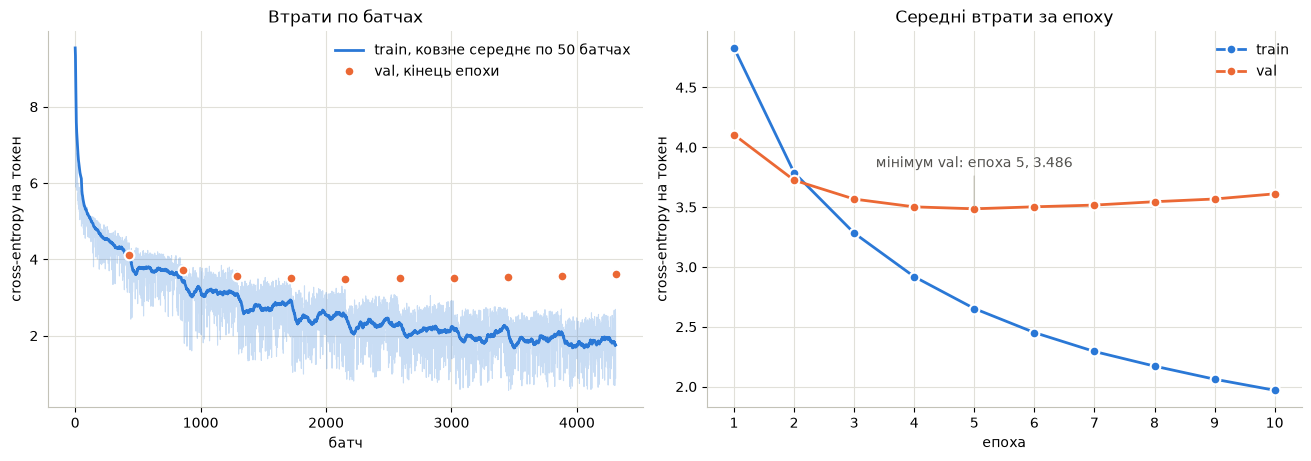

                1       2       3       4       5       6       7       8   \
train loss   4.830   3.788   3.283   2.918   2.652   2.452   2.293   2.171   
val loss     4.105   3.725   3.567   3.502   3.486   3.502   3.517   3.545   
val ppl     60.622  41.455  35.403  33.176  32.639  33.191  33.671  34.632   

                9       10  
train loss   2.062   1.969  
val loss     3.567   3.611  
val ppl     35.426  36.986  


In [13]:
steps_per_epoch = len(train_loader)
epochs = np.arange(1, EPOCHS + 1)
smooth = pd.Series(batch_history).rolling(50, min_periods=1).mean()
marker = dict(marker="o", ms=7, mec="white", mew=1.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
ax = axes[0]
ax.plot(batch_history, color=COLORS["train"], lw=0.8, alpha=0.25)
ax.plot(smooth, color=COLORS["train"], label="train, ковзне середнє по 50 батчах")
ax.plot(epochs * steps_per_epoch, history["val"], ls="none", color=COLORS["val"], label="val, кінець епохи", **marker)
ax.set_xlabel("батч")
ax.set_ylabel("cross-entropy на токен")
ax.set_title("Втрати по батчах")
ax.legend()

ax = axes[1]
ax.plot(epochs, history["train"], color=COLORS["train"], label="train", **marker)
ax.plot(epochs, history["val"], color=COLORS["val"], label="val", **marker)
ax.annotate(f"мінімум val: епоха {best_epoch}, {best_val_loss:.3f}", xy=(best_epoch, best_val_loss),
            xytext=(0, 30), textcoords="offset points", ha="center", color=INK,
            arrowprops=dict(arrowstyle="-", color=AXIS))
ax.set_xticks(epochs)
ax.set_xlabel("епоха")
ax.set_ylabel("cross-entropy на токен")
ax.set_title("Середні втрати за епоху")
ax.legend()
plt.show()

print(pd.DataFrame({"train loss": history["train"], "val loss": history["val"],
                    "val ppl": np.exp(history["val"])}, index=epochs).round(3).T)

### Аналіз графіка втрат

- Перший батч дає втрату 9.5, це майже рівно ln 13 261: модель ще нічого не знає і розподіляє
  ймовірність рівномірно по всьому англійському словнику. За першу сотню батчів втрата падає до ~5,
  бо найпростіше вивчити частоти слів, пунктуацію і те, що речення закінчується `<eos>`. Далі спад
  повільніший: тепер треба вчити відповідності між словами двох мов.
- На першій епосі val loss (4.11) нижча за train (4.83). Train loss тут середнє за всю епоху, разом
  з першими батчами, коли модель ще нічого не вміла, і рахується з dropout. Val рахується в кінці
  епохи і без dropout.
- Мінімум val loss на 5-й епосі: 3.486, перплексія 32.6. Далі val повільно росте до 3.61, а train
  падає до 1.97. Це перенавчання: модель запам'ятовує конкретні пари з train замість загальних
  закономірностей перекладу. 32 млн параметрів на 55 тис. пар забагато, найбільше їх у фінських
  ембедінгах (8 млн) і вихідному шарі (17 млн).
- Запам'ятовування видно і на лівому графіку. Всередині епохи ковзне середнє майже стоїть на місці, а
  на початку кожної нової епохи падає сходинкою на 0.3-0.5: модель знову бачить речення, які вже
  бачила. На валідацію цей спад не переноситься.
- Для перекладу беру ваги 5-ї епохи. Навчання можна було зупинити одразу після неї (early stopping),
  10 епох лишив, щоб перенавчання було видно на графіку.

## Переклад і BLEU

Жадібне декодування: на кожному кроці беру найімовірніше слово і подаю його на вхід наступного
кроку, поки не з'явиться `<eos>`, але не довше за MAX_LEN + 10 кроків. Ваги уваги з кожного кроку
зберігаю для візуалізації.

BLEU рахую по токенах у нижньому регістрі. Еталон беру як є, разом зі словами, яких немає в словнику
моделі, тож за них модель теж отримує штраф.

In [14]:
@torch.no_grad()
def greedy_decode(model, src, src_len, max_len=MAX_LEN + 10):
    model.eval()
    enc_outputs, enc_keys, hidden, mask = model.encode(src, src_len)
    token = torch.full((src.size(0),), SOS_IDX, dtype=torch.long, device=src.device)
    finished = torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
    tokens, attentions = [], []
    for _ in range(max_len):
        logits, hidden, weights = model.decoder(token, hidden, enc_keys, enc_outputs, mask)
        token = logits.argmax(dim=1)
        tokens.append(token)
        attentions.append(weights)
        finished |= token == EOS_IDX
        if finished.all():
            break
    return torch.stack(tokens, dim=1).cpu(), torch.stack(attentions, dim=1).cpu()    # (B, T), (B, T, S)


def translate(model, src_ids_list, batch_size=256):
    # для кожного речення: індекси перекладу до <eos> включно і матриця уваги (T, S)
    preds, attns = [], []
    for i in range(0, len(src_ids_list), batch_size):
        chunk = src_ids_list[i:i + batch_size]
        src_len = torch.tensor([len(s) for s in chunk])
        src = pad_sequence([torch.tensor(s) for s in chunk], batch_first=True, padding_value=PAD_IDX)
        out, attn = greedy_decode(model, src.to(device), src_len)
        for j, s in enumerate(chunk):
            ids = out[j].tolist()
            ids = ids[:ids.index(EOS_IDX) + 1] if EOS_IDX in ids else ids
            preds.append(ids)
            attns.append(attn[j, :len(ids), :len(s)].numpy())
    return preds, attns


def to_words(ids):
    return [w for w in trg_vocab.decode(ids) if w != EOS]


test_pred_ids, test_attn = translate(model, [s for s, _ in test_data])
hyps = [to_words(ids) for ids in test_pred_ids]
refs = [[tokens] for tokens in test_df.trg_tok]

print(f"BLEU на тесті ({len(hyps):,} речень): {corpus_bleu(refs, hyps) * 100:.1f}")
for lo, hi in [(3, 10), (11, 20), (21, 30)]:
    idx = np.where(test_df.src_len.between(lo, hi))[0]
    bleu = corpus_bleu([refs[i] for i in idx], [hyps[i] for i in idx])
    print(f"  фінських токенів {lo:2d}-{hi:2d}: {len(idx):5,} речень, BLEU {bleu * 100:.1f}")

n_hyp = sum(len(h) for h in hyps)
print(f"\nдовжина перекладів відносно еталону: {n_hyp / sum(len(r[0]) for r in refs):.2f}")
print(f"частка <unk> у перекладах: {sum(h.count(UNK) for h in hyps) / n_hyp:.1%}")
print(f"перекладів без <eos> (обрізані на max_len): {sum(EOS_IDX not in p for p in test_pred_ids)}")

BLEU на тесті (3,060 речень): 10.8
  фінських токенів  3-10: 1,018 речень, BLEU 12.2
  фінських токенів 11-20: 1,749 речень, BLEU 10.6
  фінських токенів 21-30:   293 речень, BLEU 10.1

довжина перекладів відносно еталону: 0.97
частка <unk> у перекладах: 3.1%
перекладів без <eos> (обрізані на max_len): 20


### Приклади з тестової вибірки

Десять випадкових речень до 20 фінських токенів.

In [15]:
def show(i):
    print("fi:     ", test_df.loc[i, SRC_LANG])
    print("еталон: ", test_df.loc[i, TRG_LANG])
    print("модель: ", " ".join(hyps[i]))
    print()

rng = np.random.default_rng(SEED)
for i in rng.choice(np.where(test_df.src_len <= 20)[0], size=10, replace=False):
    show(i)

fi:      Mielestäni muutamia näkemyksiä on pidettävä ilmeisen puolueellisina.
еталон:  My opinion is that some views are to be considered to be decidedly partisan.
модель:  i think that we have seen the same lines as a whole .

fi:      He ovat jäljittäneet kyseisen tuotteen ja estäneet markkinoilla ja maatiloilla vielä olevien tuotteiden myynnin.
еталон:  They have traced this product and blocked what remains on the market and the farms concerned.
модель:  they have been <unk> and they still have been implemented and they still have a huge amount of products .

fi:      Komissio ehdottaa tällaisen ei-toivotun seurauksen välttämiseksi siirtymäkauden jatkamista kolmella vuodella, 14. toukokuuta 2013.
еталон:  In order to avoid this unwanted effect, the Commission proposes a prolongation of the transitional period for three years until 14 May 2013.
модель:  the commission proposes to present the existing provisions of the current regulation on the current regulation , 14 may .

fi:      

П'ять найкращих перекладів за sentence BLEU серед речень від 6 фінських токенів, щоб було видно, що
модель вміє.

In [16]:
smooth_fn = SmoothingFunction().method1
sent_bleu = np.array([sentence_bleu(r, h, smoothing_function=smooth_fn) for r, h in zip(refs, hyps)])
print(f"речень з sentence BLEU > 0.5: {(sent_bleu > 0.5).mean():.1%}, з BLEU < 0.1: {(sent_bleu < 0.1).mean():.1%}\n")
best = [i for i in np.argsort(-sent_bleu, kind="stable") if test_df.src_len[i] >= 6][:5]
for i in best:
    show(i)

речень з sentence BLEU > 0.5: 1.8%, з BLEU < 0.1: 72.8%

fi:      Kiitos, komission jäsen Patten.
еталон:  Thank you, Commissioner Patten.
модель:  thank you , commissioner patten .

fi:      Tämä ehdotus voidaan panna nopeasti täytäntöön.
еталон:  This proposal can be implemented quickly.
модель:  this proposal can be implemented quickly .

fi:      (Suosionosoituksia Verts/ALE-ryhmästä)
еталон:  (Applause from the Verts/ALE Group)
модель:  ( applause from the verts / ale group )

fi:      (SK) Onnittelen esittelijää.
еталон:  - (SK) I congratulate the rapporteur.
модель:  ( sk ) i congratulate the rapporteur .

fi:      Olen ottanut vastaan seitsemän työjärjestyksen 37 artiklan 2 kohdan mukaista päätöslauselmaesitystä.
еталон:  I have received seven motions for resolutions, pursuant to Rule 37(2) of the Rules of Procedure.
модель:  i have received seven motions for resolutions pursuant to rule 37(2 ) of the rules of procedure .



## Матриці уваги

Рядок матриці це один крок декодера, тобто згенероване англійське слово, стовпці це фінські токени.
Значення в рядку це $\alpha_t$, вони сумуються в 1. Зірочкою позначені фінські слова, яких немає в
словнику: модель бачила замість них `<unk>`.

Чотири речення з тесту я вибрав після першого запуску: два перекладені правильно, в одному модель
підмінила слова частотнішими, в одному є невідоме слово. Щоб вибір не спотворював картину, нижче є
ще статистика уваги по всьому тесту.

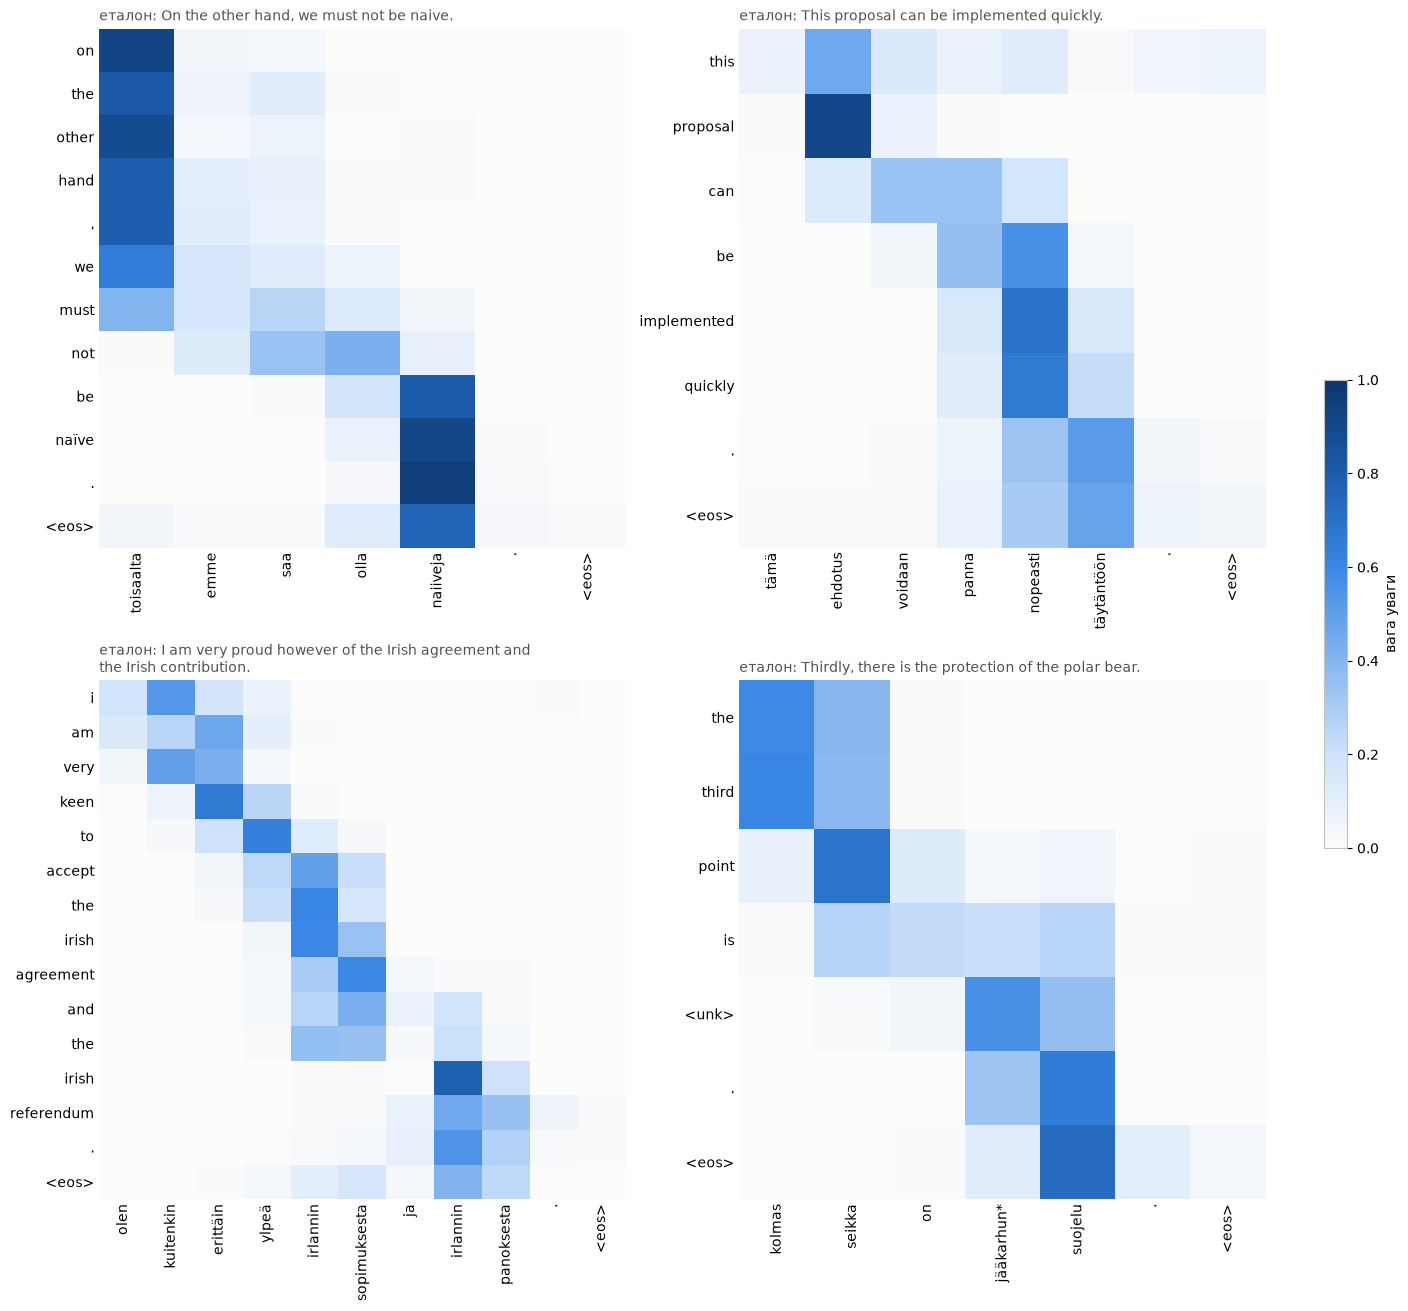

In [17]:
def src_labels(tokens):
    return [t if t in src_vocab.stoi else t + "*" for t in tokens] + [EOS]


def plot_attention(ax, src_tokens, pred_ids, attn, title=None):
    im = ax.imshow(attn, cmap=ATTN_CMAP, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(src_tokens) + 1), src_labels(src_tokens), rotation=90)
    ax.set_yticks(range(len(pred_ids)), trg_vocab.decode(pred_ids))
    ax.tick_params(length=0)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(textwrap.fill(title, 60), fontsize=10, loc="left", color=INK)
    return im


ATTN_EXAMPLES = [2832, 503, 2427, 102]

fig, axes = plt.subplots(2, 2, figsize=(14, 13), layout="constrained")
for ax, i in zip(axes.ravel(), ATTN_EXAMPLES):
    im = plot_attention(ax, test_df.src_tok[i], test_pred_ids[i], test_attn[i],
                        title="еталон: " + test_df.loc[i, TRG_LANG])
fig.colorbar(im, ax=axes, shrink=0.4, label="вага уваги")
plt.show()

fi:      Komissio ei ole vastannut kysymykseeni.
еталон:  The Commission has not answered my question.
модель:  the commission has not been consistent .

fi:      Meidän on suojeltava ympäristöä.
еталон:  We must protect the environment.
модель:  we need to protect the environment .

fi:      Euroopan unionin on tuettava Ukrainaa.
еталон:  The European Union must support Ukraine.
модель:  the european union must support the global economy .



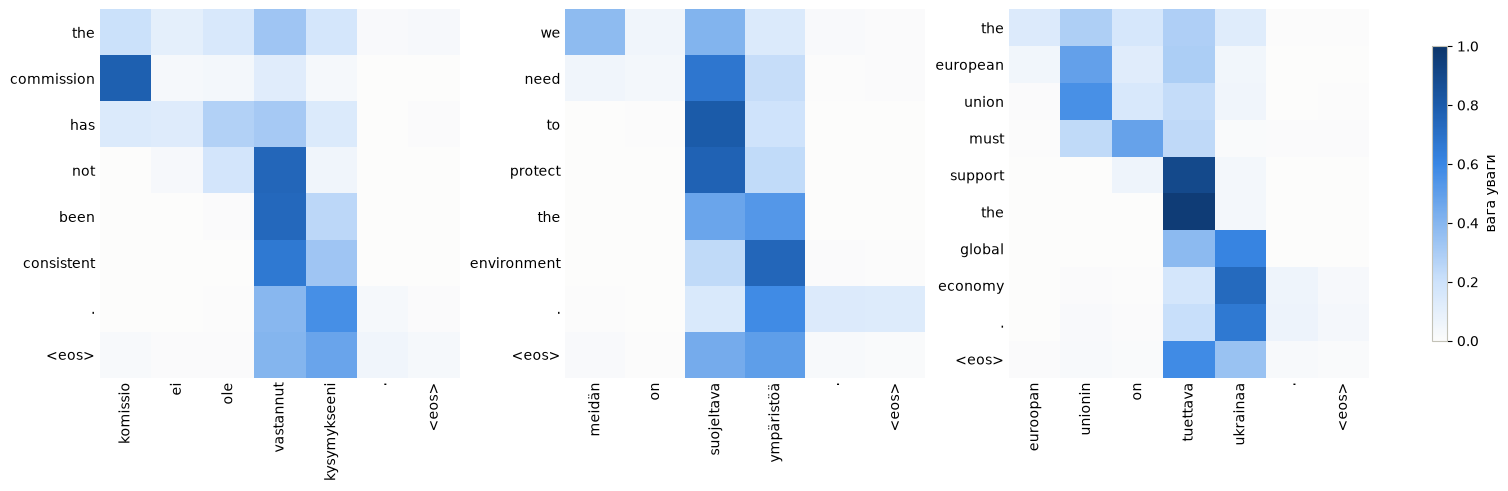

In [18]:
custom = [
    ("Komissio ei ole vastannut kysymykseeni.", "The Commission has not answered my question."),
    ("Meidän on suojeltava ympäristöä.", "We must protect the environment."),
    ("Euroopan unionin on tuettava Ukrainaa.", "The European Union must support Ukraine."),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), layout="constrained")
for ax, (text, ref) in zip(axes, custom):
    tokens = tokenize([text], SRC_LANG)[0]
    pred_ids, attn = translate(model, [src_vocab.encode(tokens) + [EOS_IDX]])
    print(f"fi:      {text}\nеталон:  {ref}\nмодель:  {' '.join(to_words(pred_ids[0]))}\n")
    im = plot_attention(ax, tokens, pred_ids[0], attn[0])
fig.colorbar(im, ax=axes, shrink=0.8, label="вага уваги")
plt.show()

### Увага на всьому тесті

Кілька матриць можуть бути нетиповими, тому дивлюся і на весь тест. Для кожного кроку декодера
беру фінський токен з найбільшою вагою і кладу на 2D-гістограму відносні позиції: крок у перекладі
і токен у джерелі. Кожен рядок нормую на 1, щоб бачити, куди дивиться модель на початку, в середині
і в кінці перекладу. Якщо увага йде вздовж речення, вийде діагональ. Друга гістограма показує, наскільки
гостра увага: яку вагу отримує найважливіший токен на кожному кроці.

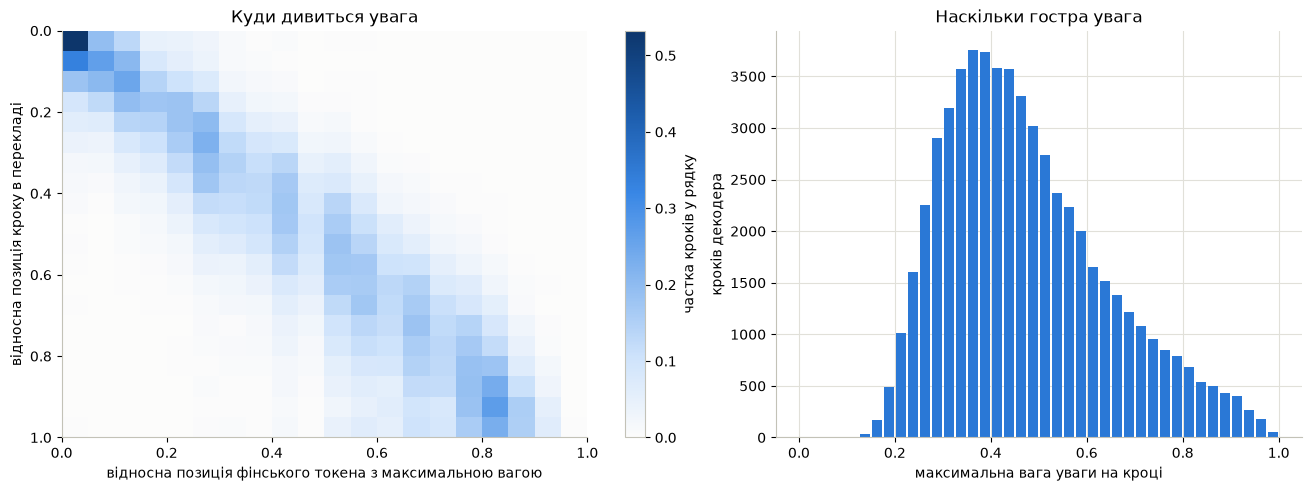

кроків декодера: 58,044
середня максимальна вага: 0.47, медіана: 0.44
кроків, де один токен отримує більше половини уваги: 38%
кореляція позицій (Пірсон): 0.88


In [19]:
rel_t, rel_s, peaks = [], [], []
for attn in test_attn:
    T, S = attn.shape
    if T < 3 or S < 3:
        continue
    rel_t.append(np.arange(T) / (T - 1))
    rel_s.append(attn.argmax(axis=1) / (S - 1))
    peaks.append(attn.max(axis=1))
rel_t, rel_s, peaks = map(np.concatenate, (rel_t, rel_s, peaks))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")
ax = axes[0]
H, _, _ = np.histogram2d(rel_t, rel_s, bins=20, range=[[0, 1], [0, 1]])
H /= H.sum(axis=1, keepdims=True)   # кожен рядок: розподіл для однієї ділянки перекладу
im = ax.imshow(H, cmap=ATTN_CMAP, vmin=0, extent=[0, 1, 1, 0], aspect="auto")
ax.grid(False)
ax.set_xlabel("відносна позиція фінського токена з максимальною вагою")
ax.set_ylabel("відносна позиція кроку в перекладі")
ax.set_title("Куди дивиться увага")
fig.colorbar(im, ax=ax, label="частка кроків у рядку")

ax = axes[1]
ax.hist(peaks, bins=40, range=(0, 1), rwidth=0.85, color=COLORS["train"])
ax.set_xlabel("максимальна вага уваги на кроці")
ax.set_ylabel("кроків декодера")
ax.set_title("Наскільки гостра увага")
plt.show()

print(f"кроків декодера: {len(peaks):,}")
print(f"середня максимальна вага: {peaks.mean():.2f}, медіана: {np.median(peaks):.2f}")
print(f"кроків, де один токен отримує більше половини уваги: {(peaks > 0.5).mean():.0%}")
print(f"кореляція позицій (Пірсон): {np.corrcoef(rel_t, rel_s)[0, 1]:.2f}")

Для кількох англійських слів дивлюся, на який фінський токен найчастіше припадає максимум уваги.

In [20]:
align = {}
for k, (ids, attn) in enumerate(zip(test_pred_ids, test_attn)):
    labels = test_df.src_tok[k] + [EOS]
    for t, w in enumerate(trg_vocab.decode(ids)):
        align.setdefault(w, Counter())[labels[attn[t].argmax()]] += 1

for w in ["commission", "parliament", "not", "must", "we", "of", "the", EOS]:
    top = ", ".join(f"{s} ({n})" for s, n in align.get(w, Counter()).most_common(5))
    print(f"{w:>11} -> {top}")

 commission -> komissio (40), komission (19), komissiota (11), ehdotus (4), neuvoston (3)
 parliament -> parlamentti (34), parlamentin (11), parlamentille (10), parlamentissa (8), parlamenttia (6)
        not -> ole (27), voi (20), saa (12), pidä (12), ei (9)
       must -> saa (9), täytyy (6), on (5), otettava (3), tehtävä (3)
         we -> olemme (21), voimme (18), emme (16), meillä (15), meidän (14)
         of -> , (28), yksi (13), kansan (13), yhteiskunnan (11), satoja (10)
        the -> komissio (27), jäsenvaltioiden (17), koko (15), tilanne (14), komission (13)
      <eos> -> <eos> (13), sen (9), huomioon (8), erityisesti (7), euroopassa (7)


### Аналіз уваги

- Загалом увага йде по діагоналі: базовий порядок слів в обох мовах SVO, і модель читає фінське
  речення зліва направо, поки пише англійське. На всьому тесті кореляція позиції кроку з позицією
  максимуму уваги 0.88.
- Одне фінське слово часто дає кілька англійських, і тоді кілька рядків поспіль дивляться в одну
  колонку. "toisaalta" дає всі чотири слова "on the other hand" з вагою близько 0.8-0.9, "suojeltava"
  (треба захищати) дає "need to protect". Для "we" у фінській часто немає окремого слова, особа
  сидить у закінченні дієслова, і максимум уваги для "we" по тесту найчастіше на olemme, voimme, emme
  (ми є, ми можемо, ми не), а також на формах займенника meillä, meidän.
- Англійські слова, яких у фінській немає, дивляться на сусіднє змістовне слово. Артиклів у фінській
  немає, і "the" дивиться на свій іменник (komissio, jäsenvaltioiden, tilanne). "this" у реченні про
  ehdotus дивиться не на "tämä", а на "ehdotus". На кроках "." і `<eos>` увага зазвичай стоїть на
  останніх словах речення, а не на крапці джерела.
- Точний збіг слово в слово моделі не потрібен. У "voidaan panna nopeasti täytäntöön" для "be",
  "implemented" і "quickly" увага стоїть на "nopeasti" посередині фрази. Стан енкодера для кожного
  токена це вихід двонаправленого GRU, він уже містить інформацію про сусідів, тому досить потрапити в
  потрібну ділянку речення. Мабуть, з тієї ж причини "not" найчастіше дивиться не на заперечне
  дієслово ei/emme, а на дієслово після нього (ole, voi, saa, pidä).
- Увага помірно гостра: найважливіший токен у середньому отримує 0.47 ваги, більше половини лише на
  38% кроків. Гостріша вона на змістовних словах (proposal, naïve, support), розмита там, де зміст
  розкладений на кілька фінських слів: для "must not" з "emme saa olla" (дослівно "нам не можна
  бути") жодне слово не отримує більше половини ваги.
- Правильна увага ще не означає правильного перекладу. Для "global economy" увага стоїть саме на
  "ukrainaa", для "not been consistent" на "vastannut" (відповіла), але обидва слова в train рідкісні
  (одиниці і десятки входжень проти тисяч у komissio), і декодер підставив частотніші. У реченні про
  Ірландію увага на правильних словах, а на виході "keen to accept" замість "proud of" і "referendum"
  замість "contribution". Невідоме "jääkarhun*" (білого ведмедя) модель бачить як `<unk>`, увага на
  ньому є, і на виході теж `<unk>`, а "suojelu" (охорона) взагалі випало.

## Висновки

Модель добре перекладає короткі і шаблонні речення і здебільшого погано змістовні речення середньої
довжини. BLEU на тесті 10.8, лише 1.8% речень мають sentence BLEU вище 0.5, а 72.8% нижче 0.1.
Зазвичай правильно виходить початок і будова речення та частотні слова, а конкретний зміст губиться.

Сильні сторони:

- Процедурні формули засідань модель перекладає майже бездоганно: подяки, оплески, привітання
  доповідача, оголошення про отримані проєкти резолюцій (п'ять найкращих перекладів вище).
- Короткі речення з частотними словами теж виходять правильними, разом з конструкціями, яких в
  англійській немає: "Meidän on suojeltava ympäristöä." → "we need to protect the environment",
  "Toisaalta emme saa olla naiiveja." → "on the other hand , we must not be naïve".
- Увагу можна прочитати: видно, з якого фінського слова взялося кожне англійське і як одне фінське
  слово розкладається на кілька англійських.

Слабкі сторони і помилки, які я помітив:

- Рідкісні і невідомі слова. 9.4% фінських токенів на валідації стають `<unk>`, здебільшого складні
  слова і рідкісні відмінкові форми. Рідкісні слова зі словника декодер підміняє частотними: "the
  global economy" замість "Ukraine", "been consistent" замість "answered my question", "referendum"
  замість "contribution". Назви і рідкісні слова на виході стають `<unk>` (3.1% слів перекладу).
- Коли модель не розуміє речення, вона видає типову парламентську фразу, майже не пов'язану з
  оригіналом: "all of the other institutions are all other groups to their families", "these are the
  big groups of the people of the poor communities...".
- Повтори і пропуски: "the charter of the charter of fundamental rights", "the current regulation on
  the current regulation", "25 % of 25 %"; слова "kuitenkin" (however) і "suojelu" (protection) просто
  зникли. 20 перекладів з 3060 так і не видали `<eos>` і обрізані на ліміті довжини. Жадібне
  декодування не може виправити вже вибране слово, а декодер не веде обліку, які слова джерела вже
  перекладені.
- Довші речення перекладаються гірше: BLEU 12.2 для 3-10 токенів, 10.6 для 11-20, 10.1 для 21-30. У
  довгому реченні більше рідкісних слів і більше кроків, на яких жадібне декодування може збитися, а
  одна помилка тягне за собою наступні.
- Перенавчання вже після 5-ї епохи.

Що покращило б переклад: субсловна токенізація (BPE, SentencePiece), яка ділить фінські форми на
основу і закінчення і майже прибирає `<unk>`; beam search замість жадібного декодування; більше даних
і сильніша регуляризація; трансформер замість GRU.